In [1]:
import pandas as pd

In [3]:
sezoane = ['1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425', '2526', '2627']
url = "https://www.football-data.co.uk/mmz4281/{}/E0.csv"

df = pd.concat([pd.read_csv(url.format(s)).assign(Sezon=s) for s in sezoane])
df = df[['Sezon', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']]

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')
print(df['FTR'].value_counts(normalize=True))

FTR
H    0.445195
A    0.321299
D    0.233506
Name: proportion, dtype: float64


In [4]:
print(df['Date'].isna().sum())
print(df['Date'].min(), df['Date'].max())

0
2016-08-13 00:00:00 2026-09-20 00:00:00


In [13]:
recent = df[df["Date"] >= '2024-08-01'].dropna(subset=['FTHG', 'FTAG'])
goals = pd.concat([
    pd.DataFrame({"team": recent["HomeTeam"], 'opponet': recent["AwayTeam"], 'home': 1, 'goals': recent["FTHG"]}),
    pd.DataFrame({'team': recent['AwayTeam'], 'opponent': recent['HomeTeam'], 'home': 0, 'goals': recent["FTAG"]}),
])

print(len(goals))

1620


In [14]:
print(goals.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['team', 'opponet', 'home', 'goals', 'opponent'], dtype='object')>


In [44]:
from sklearn.linear_model import PoissonRegressor

X = pd.get_dummies(goals[["team", "opponent"]]).astype(float)
X["home"] = goals["home"].values
coloane = X.columns

reg = PoissonRegressor(alpha=0.005, max_iter=1000).fit(X, goals["goals"])
print(dict(zip(coloane, reg.coef_))["home"])

0.12866584974479667


In [45]:
import numpy as np
from scipy.stats import poisson

def prezice(gazda, oaspete):
    rand = pd.DataFrame(0.0, index=[0, 1], columns=coloane)
    rand.loc[0, ["team_" + gazda, "opponent_" + oaspete, "home"]] = 1
    rand.loc[1, ["team_" + oaspete, "opponent_" + gazda]] = 1
    lg, lo = reg.predict(rand)
    m = np.outer(poisson.pmf(range(10), lg), poisson.pmf(range(10), lo))
    return {"H": round(np.tril(m, -1).sum(), 3), "D": round(np.trace(m), 3), "A": round(np.triu(m, 1).sum(), 3)}

prezice("Liverpool", "Man City")

{'H': np.float64(0.426), 'D': np.float64(0.241), 'A': np.float64(0.334)}

In [46]:
sezon = df[df["Sezon"] == "2627"].dropna(subset=["FTHG", "FTAG"])
echipe = sorted(set(sezon["HomeTeam"]) | set(sezon["AwayTeam"]))
jucate = set(zip(sezon["HomeTeam"], sezon["AwayTeam"]))

ramase = [(h, a) for h in echipe for a in echipe if h != a and (h, a) not in jucate]
print(len(echipe), len(jucate), len(ramase))

20 50 330


In [47]:
pred = pd.DataFrame([{"Gazda": h, "Oaspete": a, **prezice(h, a)} for h, a in ramase])
pred["Favorit"] = pred[["H", "D", "A"]].idxmax(axis=1)
pred.sort_values("H", ascending=False)

,Gazda,Oaspete,H,D,A,Favorit
8,Arsenal,Ipswich,0.842,0.108,0.050,H
241,Man City,Ipswich,0.837,0.104,0.058,H
225,Liverpool,Ipswich,0.831,0.109,0.059,H
221,Liverpool,Coventry,0.800,0.132,0.067,H
74,Brighton,Ipswich,0.758,0.146,0.095,H
...,...,...,...,...,...,...
109,Coventry,Liverpool,0.101,0.166,0.733,A
110,Coventry,Man City,0.100,0.160,0.739,A
194,Ipswich,Man City,0.091,0.137,0.772,A
99,Coventry,Arsenal,0.085,0.167,0.747,A


In [48]:
puncte0 = {e: 0 for e in echipe}
gd0 = {e: 0 for e in echipe}
for _, r in sezon.iterrows():
    h, a, gh, ga = r["HomeTeam"], r["AwayTeam"], r["FTHG"], r["FTAG"]
    puncte0[h] += 3 if gh > ga else (1 if gh == ga else 0)
    puncte0[a] += 3 if ga > gh else (1 if gh == ga else 0)
    gd0[h] += gh - ga
    gd0[a] += ga - gh

In [49]:
lam = []
for h, a in ramase:
    rand = pd.DataFrame(0.0, index=[0, 1], columns=coloane)
    rand.loc[0, ["team_" + h, "opponent_" + a, "home"]] = 1
    rand.loc[1, ["team_" + a, "opponent_" + h]] = 1
    lam.append(reg.predict(rand))
lam = np.array(lam)
print(lam.shape)

(330, 2)


In [50]:
N = 10000
rng = np.random.default_rng(42)
gh = rng.poisson(lam[:, 0], size=(N, len(ramase)))
ga = rng.poisson(lam[:, 1], size=(N, len(ramase)))

idx = {e: i for i, e in enumerate(echipe)}
H = np.array([idx[h] for h, a in ramase])
A = np.array([idx[a] for h, a in ramase])

In [51]:
pts = np.tile([puncte0[e] for e in echipe], (N, 1)).astype(float)
gd = np.tile([gd0[e] for e in echipe], (N, 1)).astype(float)

for j in range(len(ramase)):
    pts[:, H[j]] += np.where(gh[:, j] > ga[:, j], 3, np.where(gh[:, j] == ga[:, j], 1, 0))
    pts[:, A[j]] += np.where(ga[:, j] > gh[:, j], 3, np.where(gh[:, j] == ga[:, j], 1, 0))
    gd[:, H[j]] += gh[:, j] - ga[:, j]
    gd[:, A[j]] += ga[:, j] - gh[:, j]

In [52]:
scor = pts + gd / 1000
loc = (-scor).argsort(axis=1).argsort(axis=1) + 1

rez = pd.DataFrame({
    "Puncte medii": pts.mean(axis=0),
    "Titlu %": (loc == 1).mean(axis=0) * 100,
    "Top 4 %": (loc <= 4).mean(axis=0) * 100,
    "Retrogradare %": (loc >= 18).mean(axis=0) * 100,
}, index=echipe).sort_values("Puncte medii", ascending=False).round(1)
rez

,Puncte medii,Titlu %,Top 4 %,Retrogradare %
Arsenal,76.1,44.2,95.0,0.0
Man City,75.1,37.6,93.2,0.0
Liverpool,69.4,13.6,77.4,0.0
Brighton,62.0,2.3,40.3,0.0
Chelsea,58.2,0.7,19.1,0.3
Bournemouth,56.3,0.3,13.7,0.5
Leeds,56.3,0.4,12.9,0.4
Newcastle,55.4,0.2,11.1,0.6
Brentford,55.2,0.4,10.8,0.7
Hull,54.4,0.2,8.6,0.6


In [41]:
coef = pd.Series(reg.coef_, index=coloane)
print(coef[["team_Hull", "opponent_Hull", "team_Coventry", "opponent_Coventry"]])
print(goals[goals["team"].isin(["Hull", "Coventry"])].groupby("team")["goals"].agg(["count", "sum"]))

team_Hull           -0.216397
opponent_Hull       -1.892224
team_Coventry       -1.442551
opponent_Coventry    0.887200
dtype: float64
          count  sum
team                
Coventry      5    1
Hull          5    6


In [53]:
def lung(m):
    a = pd.DataFrame({"team": m["HomeTeam"], "opponent": m["AwayTeam"], "home": 1, "goals": m["FTHG"]})
    b = pd.DataFrame({"team": m["AwayTeam"], "opponent": m["HomeTeam"], "home": 0, "goals": m["FTAG"]})
    return pd.concat([a, b], ignore_index=True)

train = df[df["Sezon"].isin(["2324", "2425"])].dropna(subset=["FTHG", "FTAG"])
test = df[df["Sezon"] == "2526"].dropna(subset=["FTHG", "FTAG"]).reset_index(drop=True)
print(len(train), len(test))

760 380


In [54]:
def prob_meciuri(model, coloane, meciuri):
    n = len(meciuri)
    Xh = pd.DataFrame(0.0, index=range(n), columns=coloane)
    Xa = pd.DataFrame(0.0, index=range(n), columns=coloane)
    for i, (h, a) in enumerate(zip(meciuri["HomeTeam"], meciuri["AwayTeam"])):
        for X, t, o in [(Xh, h, a), (Xa, a, h)]:
            if "team_" + t in coloane: X.loc[i, "team_" + t] = 1
            if "opponent_" + o in coloane: X.loc[i, "opponent_" + o] = 1
    Xh["home"] = 1
    lh, la = model.predict(Xh), model.predict(Xa)

    g = np.arange(10)
    m = poisson.pmf(g, lh[:, None])[:, :, None] * poisson.pmf(g, la[:, None])[:, None, :]
    p = np.column_stack([np.tril(m, -1).sum(axis=(1, 2)), np.trace(m, axis1=1, axis2=2), np.triu(m, 1).sum(axis=(1, 2))])
    return p / p.sum(axis=1, keepdims=True)

In [55]:
from sklearn.metrics import log_loss, accuracy_score

y = test["FTR"].map({"H": 0, "D": 1, "A": 2}).values
g_train = lung(train)
Xt = pd.get_dummies(g_train[["team", "opponent"]]).astype(float)
Xt["home"] = g_train["home"].values

for alpha in [0.001, 0.005, 0.01, 0.05, 0.1]:
    m_t = PoissonRegressor(alpha=alpha, max_iter=1000).fit(Xt, g_train["goals"])
    p = prob_meciuri(m_t, Xt.columns, test)
    print(alpha, round(log_loss(y, p, labels=[0, 1, 2]), 4), round(accuracy_score(y, p.argmax(axis=1)), 3))

0.001 1.0313 0.474
0.005 1.0312 0.474
0.01 1.0315 0.476
0.05 1.039 0.479
0.1 1.0482 0.461


In [57]:
cote = pd.read_csv(url.format("2526"))[["HomeTeam", "AwayTeam", "AvgH", "AvgD", "AvgA"]]
test_c = test.merge(cote, on=["HomeTeam", "AwayTeam"], how="left")
print(test_c[["AvgH", "AvgD", "AvgA"]].isna().sum().sum())

imp = 1 / test_c[["AvgH", "AvgD", "AvgA"]].values
p_case = imp / imp.sum(axis=1, keepdims=True)
print("Case de pariuri:", round(log_loss(y, p_case), 4), round(accuracy_score(y, p_case.argmax(axis=1)), 3))

0
Case de pariuri: 1.0153 0.495


[1.085174234704821, 1.0315, 1.0152523829672504]


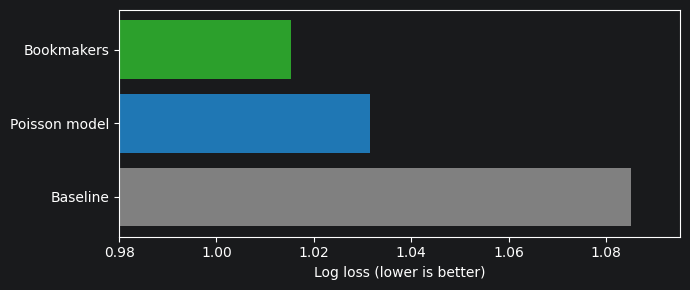

In [62]:
import os
import matplotlib.pyplot as plt

f = train["FTR"].value_counts(normalize=True)[["H", "D", "A"]].values
p_base = np.tile(f, (len(test), 1))
print("Baseline:", round(log_loss(y, p_base), 4), round(accuracy_score(y, np.zeros(len(y))), 3))

nume = ["Baseline", "Poisson model", "Bookmakers"]
valori = [log_loss(y, p_base), 1.0315, log_loss(y, p_case)]
print(valori)

plt.figure(figsize=(7, 3))
plt.barh(nume, valori, color=["grey", "tab:blue", "tab:green"])
plt.xlim(0.98, max(valori) + 0.01)
plt.xlabel("Log loss (lower is better)")
plt.tight_layout()
os.makedirs("imagini", exist_ok=True)
plt.savefig("imagini/evaluare.png", dpi=150)